# Miniproyecto 3: Clasificación de animales

## Entrega 4
En las entregas anteriores, exploramos diversos tipos de descriptores que pueden ayudarnos a resolver la tarea de clasificación. Hasta ahora, hemos experimentado con el clasificador de vecino más cercano y las Máquinas de Soporte Vectorial (SVMs).

En esta entrega, integraremos diferentes clasificadores dentro de un método de modelos de expertos. Los clasificadores que utilizaremos serán: SVMs, Random Forests, MLPs (Redes Neuronales Multicapa).

In [1]:
# importar librerias
import os
import random
import numpy as np
from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt

import cv2
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


In [2]:
group = 13

In [3]:
def determine_classes(group: int) -> list:
    """Función que determina las clases a utilizar en el proyecto.

    Args:
        group (int): Número de grupo.

    Returns:
        list: Lista con los nombres de las clases a utilizar.
    """
    # Se fija la semilla para reproducibilidad
    random.seed(group)
    
    # Se obtienen las categorías y la cantidad de imágenes por categoría
    stats = [('Canis latrans', 1286), ('Castor canadensis', 854), ('Dasypus novemcinctus', 515), ('Didelphis virginiana', 713), 
             ('Lepus californicus', 515), ('Lynx rufus', 854), ('Megaptera novaeangliae', 515), ('Mephitis mephitis', 515), 
             ('Odocoileus hemionus', 1286), ('Odocoileus virginianus', 1795), ('Otospermophilus beecheyi', 854), 
             ('Otospermophilus variegatus', 515), ('Phoca vitulina', 713), ('Procyon lotor', 1286), ('Sciurus carolinensis', 1795), 
             ('Sciurus niger', 1795), ('Sylvilagus audubonii', 515), ('Sylvilagus floridanus', 854), ('Tamias striatus', 854), 
             ('Tamiasciurus hudsonicus', 713), ('Urocyon cinereoargenteus', 515), ('Ursus americanus', 713), ('Vulpes vulpes', 854)]
    
    # Se agrupan las categorías por cantidad de imágenes
    clusters = {}
    for category, num_images in stats:
        if num_images in clusters:
            clusters[num_images].append(category)
        else:
            clusters[num_images] = [category]
    
    # Se selecciona una categoría aleatoria de cada cluster
    categories = []
    for cluster_categories in clusters.values():
        categories += [random.choice(cluster_categories)]
    return categories

assert group is not None, "Por favor, asigna un número de grupo a la variable 'group'."
assert group > 0, "El número de grupo debe ser mayor que 0."
assert group <= 28, "El número de grupo debe ser menor o igual que 28."

categories = determine_classes(group)
print(f"Las classes que usarán en este Mini-proyecto serán:\n{", ".join(categories)}.")

Las classes que usarán en este Mini-proyecto serán:
Odocoileus hemionus, Otospermophilus beecheyi, Sylvilagus audubonii, Phoca vitulina, Sciurus niger.


In [4]:
ict_labels = {} # Cambiar por un diccionario con las etiquetas de las clases 

# YOUR CODE HERE
clases= ["Odocoileus hemionus","Otospermophilus beecheyi","Phoca vitulina","Sciurus niger", "Sylvilagus audubonii"]
dict_labels={"Odocoileus hemionus":0, "Otospermophilus beecheyi":1,"Phoca vitulina":2,"Sciurus niger":3, "Sylvilagus audubonii":4}


def get_data(subset: str) -> tuple[list, list]:
    """Función que obtiene las rutas de las imágenes y sus etiquetas.

    Args:
        subset (str): Nombre del subconjunto de datos

    Returns:
        tuple[list, list]: Rutas de las imágenes y sus etiquetas.
    """
    
    
    paths=[] # Cambiar por una lista con las rutas de las imágenes 
    labels=[] # Cambiar por una lista con las etiquetas de las imágenes
    
    # Construimos la ruta base al subconjunto (train, valid o test)
    
    base_path=f"dataset/{subset}"
    
    # Recorremos cada una de las clases que nos asignaron
    for nombre in clases:
        # Construimos la ruta de la carpeta de esa clase
        class_path = os.path.join(base_path, nombre)
        # Usamos glob para obtener todas las imágenes dentro de esa carpeta
        image_paths = glob(os.path.join(class_path, "*"))
        # Ahora recorremos cada imagen encontrada
        for img_path in image_paths:
            # Guardamos la ruta de la imagen
            paths.append(img_path)
            # Guardamos la etiqueta correspondiente usando el diccionario
            # Convertimos el nombre de la clase a su ID numérico
            labels.append(dict_labels[nombre])
    # Al final devolvemos ambas listas
    return paths, labels
train_paths, train_labels = get_data("train")
valid_paths, valid_labels = get_data("valid")
test_paths, test_labels = get_data("test")

In [5]:
assert len(train_paths) > 0, "No se ha cargado ningún dato de entrenamiento"
assert len(train_paths) == 5163, "El número de datos de entrenamiento no es correcto"
assert len(valid_paths) > 0, "No se ha cargado ningún dato de validación"
assert len(valid_paths) == 1723, "El número de datos de validación no es correcto"
assert len(test_paths) > 0, "No se ha cargado ningún dato de test"
assert len(test_paths) == 1724, "El número de datos de test no es correcto"

assert type(train_paths[0]) == str, "Los datos de entrenamiento no tienen la forma correcta"
assert type(valid_paths[0]) == str, "Los datos de validación no tienen la forma correcta"
assert type(test_paths[0]) == str, "Los datos de test no tienen la forma correcta"

assert type(train_labels[0]) == int, "Las etiquetas de entrenamiento no tienen la forma correcta"
assert type(valid_labels[0]) == int, "Las etiquetas de validación no tienen la forma correcta"
assert type(test_labels[0]) == int, "Las etiquetas de test no tienen la forma correcta"

assert len(dict_labels) == len(categories), "El diccionario de labels no tiene la longitud correcta"

categories_sorted = sorted(categories)
assert list(dict_labels.keys()) == categories_sorted, "Las llaves del diccionario de labels no son correctas"
assert list(dict_labels.values()) == list(range(len(categories))), "Los valores del diccionario de labels no son correctos"

assert min([dict_labels[train_paths[i].split(os.sep)[-2]] == train_labels[i] for i in range(len(train_paths))]), "Las etiquetas de entrenamiento no coinciden"
assert min([dict_labels[valid_paths[i].split(os.sep)[-2]] == valid_labels[i] for i in range(len(valid_paths))]), "Las etiquetas de validación no coinciden"
assert min([dict_labels[test_paths[i].split(os.sep)[-2]] == test_labels[i] for i in range(len(test_paths))]), "Las etiquetas de test no coinciden"

In [6]:
def processing(Im: np.ndarray, img_size: tuple[int] | None = None, color_space: str | None = None) -> np.ndarray:
    """Función que preprocesa una lista de imágenes.

    Args:
        Im_list (list[np.ndarray]): Lista con las imágenes a preprocesar.
        img_size (tuple[int] | None): Tamaño de la imagen.
        color_space (str | None): Espacio de color a utilizar. Puede ser "rgb", "gray", "hsv" o "lab".

    Returns:
        list[np.ndarray]: Lista con las imágenes preprocesadas.
    """
    
    Im_processed = Im.copy()
    
    if img_size is not None:
        Im_processed = cv2.resize(Im_processed, img_size)
        
    if color_space is not None:
        color_space = color_space.lower()
        if color_space == "rgb":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2RGB)
        elif color_space == "gray":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2GRAY)
        elif color_space == "hsv":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2HSV)
        elif color_space == "lab":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2LAB)
    
    return Im_processed

In [7]:
Im_list = [cv2.imread(path) for path in train_paths[:5]]
img_size = (224, 224)
color_space = "rgb"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]

assert len(Im_proc) == len(Im_list), "El número de imágenes preprocesadas no es correcto"
assert type(Im_proc) == list, "Las imágenes preprocesadas no están en una lista"
assert type(Im_proc[0]) == np.ndarray, "Las imágenes preprocesadas no son arreglos de numpy"
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2RGB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "gray"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2GRAY), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "hsv"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2HSV), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "lab"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2LAB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

Im_proc = [processing(Im, (256, 256)) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (256, 256, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.resize(Im_list[0], (256, 256)), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

Im_proc = [processing(Im, None, "lab") for Im in Im_list]
assert np.array_equal(cv2.cvtColor(Im_list[0], cv2.COLOR_BGR2LAB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

#### Parte 1.1: Modelo de expertos
En entregas anteriores, nos hemos centrado en la experimentación con descriptores y en aumentar la dimensionalidad de estos agregando información adicional, con la expectativa de mejorar los resultados. Otra estrategia interesante es entrenar diferentes modelos especializados en descriptores específicos. Por ejemplo, podemos entrenar un modelo experto en diferenciar imágenes por su forma y otro por su color. Cada modelo hará su predicción, y al final realizaremos una votación entre ellos para obtener la clasificación final.

Para este experimento, utilizaremos descriptores sencillos como forma o pirámide de colores. Antes de iniciar, copiaremos algunas funciones necesarias para realizar las pruebas.

In [8]:
def color_hist(Im: np.ndarray, type_h: str, bins: int) -> np.ndarray:
    """Función que calcula el histograma de color conjunto o concatenado de una imagen

    Args:
        Im (numpy.ndarray): Imagen a la que calcular el histograma
        type_h (str): Tipo de histograma a calcular, puede ser "concat" o "joint"
        bins (int): Cantidad de bins que usar en el histograma. En el caso de concat el número de bins finale será 3*bins
        En el caso de Joint será bins^3
        
    Returns:
        numpy.ndarray: Histograma de color normalizado
    """
    h = "" # Histograma de color normalizado
    
    if type_h.lower() == "concat":
        h = []
        for c in range(Im.shape[2]):
            hist, _ = np.histogram(Im[:, :, c].flatten(), bins=bins)
            h.append(hist)
        h = np.concatenate(h).astype(float)

    elif type_h.lower() == "joint":
        h, _ = np.histogramdd(
            Im.reshape(-1, 3).astype(float),
            bins=bins
        )
        h = h.flatten()

    h = h / h.sum()
    return h

def Color_pyramid(Im: np.ndarray, patch_sizes: list[tuple[int]], type_h: str, bins:int) -> np.ndarray:
    """Función que calcula el histograma de color de una imagen por parches

    Args:
        Im (numpy.ndarray): Imagen de entrada
        patch_sizes (list[tuple[int]]): Tupla tamaño de los parches sobre el que calcular cada histograma
        type_h (str): Puede ser "concat" o "joint"
        bins (int): Cantidad de bins que usar en el histograma

    Returns:
        numpy.ndarray: Histograma de color por pirámide espacial
    """
    histograms = []

    H, W = Im.shape[:2]

    # Recorrer cada nivel de la pirámide
    for patch_h, patch_w in patch_sizes:

        # Recorrer parches de arriba a abajo y de izquierda a derecha
        for i in range(0, H, patch_h):
            for j in range(0, W, patch_w):

                # Extraer parche
                patch = Im[i:i + patch_h, j:j + patch_w]

                # Calcular histograma del parche
                h = color_hist(patch, type_h, bins)

                # Guardar histograma
                histograms.append(h)

    # Concatenar todos los histogramas
    final_histogram = np.concatenate(histograms)

    return final_histogram

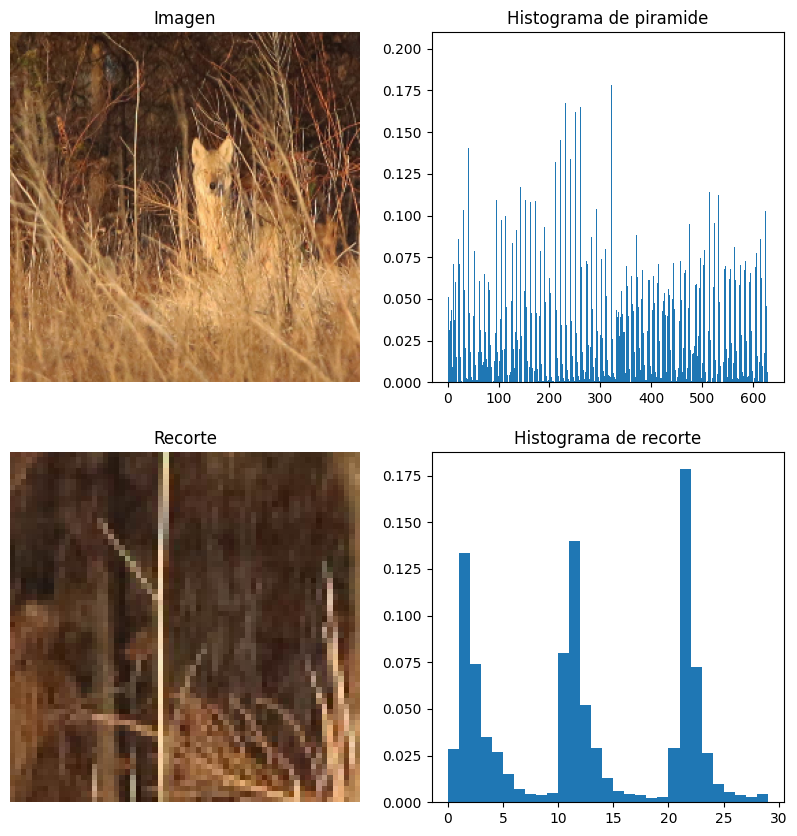

In [9]:
img=processing(cv2.imread(os.path.join(".", "dataset", "train", "Canis latrans", "f494fab00ebb2d87c8d3bf5215560d54.jpg")),  (256, 256), 'rgb')
h_pyramid_cat=Color_pyramid(img,[(256, 256), (128, 128), (64, 64)],'concat',10)
h_pyramid_joint=Color_pyramid(img,[(256, 256), (128, 128), (64, 64)],'joint',5)

fig,ax=plt.subplots(2,2,figsize=(10,10))
ax[0,0].imshow(img)
ax[0,0].axis('off')
ax[0,0].set_title('Imagen')
ax[0,1].hist(list(range(len(h_pyramid_cat))), list(range(len(h_pyramid_cat - 1))), weights = h_pyramid_cat)
ax[0,1].set_title('Histograma de piramide')

assert len(h_pyramid_cat)==30*(1+4+16), 'La longitud del descriptor final debe ser igual a la longitud del histograma concatenado multiplicado por la cantidad de cuadrantes dentro de la imagen'
assert np.isclose(np.sum(h_pyramid_cat),(1+4+16),0.01), 'En total se tienen 64 histogramas normalizados juntos, la suma de todo debe ser 64'
assert len(h_pyramid_joint)==5**3*(1+4+16), 'La longitud del descriptor final debe ser igual a la longitud del histograma conjunto multiplicado por la cantidad de cuadrantes dentro de la imagen'
assert np.isclose(np.sum(h_pyramid_joint),(1+4+16),0.01), 'En total se tienen 64 histogramas normalizados juntos, la suma de todo debe ser 64'
a=color_hist(img[64:64+64,64:64+64,:],'concat',10)
K=10
b=h_pyramid_cat[K*30:K*30+30]

ax[1,0].imshow(img[64:64+64,64:64+64,:])
ax[1,0].axis('off')
ax[1,0].set_title('Recorte')
ax[1,1].hist(list(range(len(h_pyramid_cat[K*30:K*30+30]))), list(range(len(h_pyramid_cat[K*30:K*30+30] - 1))), weights = h_pyramid_cat[K*30:K*30+30])
ax[1,1].set_title('Histograma de recorte')

assert np.array_equal(a,b), 'El histograma concatenado de el cuadrante 17 de la imagen debe ser igual la parte 17 del histograma en piramide'

##### Parte 1.2.1: SVM
Obtén el descriptor de forma de todas las imágenes del subconjunto de entrenamiento y realiza el mismo proceso para obtener el descriptor de color mediante un histograma concatenado en pirámide. Luego, extrae los descriptores de todas las imágenes de validación para evaluar el modelo. No olvides incluir la lista de etiquetas (labels) correspondientes para cada conjunto de datos, tanto para entrenamiento como para validación.

**Nota:** Recuerde que para ser consistentes en los descriptores debe utilizar la función `resize` para cambiar el tamaño de las imágenes a $256\times256$. Puede utilizar otro tamaño si considera necesario pero debe ser consistente a lo largo de toda la entrega.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert len(train_labels) == train_images_num, 'La cantidad de etiquetas que tiene debe ser igual a la cantidad de imagenes que usted especificó'
assert len(shape_des_train) == len(color_des_train) and len(shape_des_valid) == len(color_des_valid), 'Usted debe tener la misma cantidad de descriptores en todas las listas'
assert len(shape_des_train[0]) > 1, 'El descriptor debe tener más de una dimensión'
assert len(color_des_train[0]) > 1, 'El descriptor debe tener más de una dimensión'
assert len(color_des_train[0]) <= 7056, 'Su descriptor unimodal de color tiene demasiadas dimensiones'
assert len(shape_des_train[0]) <= 7056, 'Su descriptor unimodal de forma tiene demasiadas dimensiones'
assert len(np.unique(train_labels)) == 5, 'Solo deben haber 5 etiquetas'
assert len(np.unique(valid_labels)) == 5, 'Solo deben haber 5 etiquetas'

assert len(valid_labels) == 1723, 'Usted debe sacar el descriptor de todas las imagenes de validación'
assert len(color_des_train[0]) == len(color_des_valid[0]), 'El descriptor en train y valid debe ser igual'
assert len(shape_des_train[0]) == len(shape_des_valid[0]), 'El descriptor en train y valid debe ser igual'

print(f"Las dimensiones de su descriptor de color son {np.array(color_des_train).shape[1]}")
print(f"Las dimensiones de su descriptor de forma son {np.array(shape_des_train).shape[1]}")

Luego, entrene un modelo SVM **con el parametro de probability=True**.

In [ ]:
svm_color='' #modelo SVM entrenado con color
svm_shape='' #modelo SVM entrenado con forma

# YOUR CODE HERE
raise NotImplementedError()

Ya tenemos dos modelos, cada uno especializado en un tipo de descriptor. Ahora utilizaremos el método `.predict_proba` para obtener la probabilidad de cada clase según la predicción de cada modelo. A continuación, promediaremos las probabilidades de ambos modelos para cada clase de forma independiente. Por ejemplo, si una predicción devuelve las probabilidades [0.1, 0.4, 0.5] y la otra [0.3, 0.3, 0.4], el promedio final será [0.2, 0.35, 0.45]. Finalmente, selecciona la etiqueta con la mayor probabilidad.

Primero, realiza las predicciones utilizando el método `.predict_proba` para cada uno de los modelos expertos y guárdalas en las variables correspondientes en la siguiente celda.

In [ ]:
proba_color_valid=[] #lista de probabilidades de todas las imagenes de validación en color
proba_shape_valid=[] #lista de probabilidades de todas las imagenes de validación en forma

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert len(proba_color_valid)==1723, 'Debería tener 1723 datos de predicción'
assert len(proba_shape_valid)==1723, 'Debería tener 1723 datos de predicción'
assert np.isclose(np.mean(np.sum(proba_color_valid,axis=1)),1), 'La suma de las probabilidades debe ser 1'
assert svm_color.n_features_in_==len(color_des_train[0]), 'Usted entrenó el modelo de color con un descriptor diferente al de color'
assert svm_shape.n_features_in_==len(shape_des_train[0]), 'Usted entrenó el modelo de forma con un descriptor diferente al de forma'
assert not np.array_equal(proba_color_valid,proba_shape_valid), 'Sus probabilidades no son diferentes'
assert np.array_equal(proba_color_valid[0],svm_color.predict_proba([color_des_valid[0]])[0]), 'Las probabilidades de color estan mal calculadas'

Ahora, promedia las probabilidades obtenidas para cada una de las clases. Finalmente, para cada imagen, la predicción final será la clase con la mayor probabilidad.

In [ ]:
final_predict=[] #predicción final por expertos
color_predict=[] #predicción final por color
shape_predict=[] #predicción final por forma
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
color_p=proba_color_valid[0]
shape_p=proba_shape_valid[0]

assert np.isclose(((color_p+shape_p)/2)[final_predict[0]],np.max(((color_p+shape_p)/2))), 'La probabilidad maxima no fue seleccionada como la etiqueta de predicción final'

In [ ]:
f_color=f1_score(valid_labels,color_predict,average='macro')
f_shape=f1_score(valid_labels,shape_predict,average='macro')
f_final=f1_score(valid_labels,final_predict,average='macro')

print(f'color: {f_color}')
print(f'forma: {f_shape}')
print(f'final: {f_final}')

In [ ]:
assert f_color<0.8, 'Usted esta validando con los mismos datos que entrenó'
assert f_shape<0.8, 'Usted esta validando con los mismos datos que entrenó'
assert f_final<0.8, 'Usted esta validando con los mismos datos que entrenó'

##### Parte 1.2.2: Exploración con otros clasificadores
En esta parte, repetiremos el mismo procedimiento que en la sección anterior, pero cambiando el clasificador de SVM a Random Forest o Redes Neuronales (MLP). Los descriptores ya están calculados, por lo que ahora solo necesitas entrenar un nuevo modelo de Random Forest y MLP utilizando sklearn, y luego calcular las probabilidades de predicción para cada clase.

**Nota:** El MLP se entrena en un número determinado de iteraciones. El número predeterminado de iteraciones es 200, pero puede que el modelo no converja en ese tiempo. Aumenta el número de iteraciones si es necesario.

In [ ]:
RF_color='' #modelo RF entrenado con color
RF_shape='' #modelo RF entrenado con forma

MLP_color='' #modelo MLP entrenado con color
MLP_shape='' #modelo MLP entrenado con forma

# YOUR CODE HERE
raise NotImplementedError()

Ahora realizaremos la predicción de probabilidades para cada modelo y para cada imagen. Nuevamente, utilizaremos el método `.predict_proba` para obtener las probabilidades de predicción de cada clase.

In [ ]:
proba_color_valid_RF='' #lista de probabilidades de color en validación Random Forest
proba_shape_valid_RF='' #lista de probabilidades de forma en validación Random Forest

proba_color_valid_MLP='' #lista de probabilidades de color en validación MLP
proba_shape_valid_MLP='' #lista de probabilidades de forma en validación MLP

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert len(proba_color_valid_RF)==1723, 'Debería tener 500 datos de predicción'
assert len(proba_shape_valid_RF)==1723, 'Debería tener 500 datos de predicción'
assert len(proba_color_valid_MLP)==1723, 'Debería tener 500 datos de predicción'
assert len(proba_shape_valid_MLP)==1723, 'Debería tener 500 datos de predicción'
assert np.isclose(np.mean(np.sum(proba_color_valid_RF,axis=1)),1), 'La suma de las probabilidades debe ser 1'
assert np.isclose(np.mean(np.sum(proba_color_valid_MLP,axis=1)),1), 'La suma de las probabilidades debe ser 1'
assert RF_color.n_features_in_==len(color_des_train[0]), 'Usted entrenó el modelo de color con un descriptor diferente al de color'
assert MLP_shape.n_features_in_==len(shape_des_train[0]), 'Usted entrenó el modelo de forma con un descriptor diferente al de forma'
assert not np.array_equal(proba_color_valid_RF,proba_shape_valid_RF), 'Sus probabilidades no son diferentes'
assert not np.array_equal(proba_color_valid_MLP,proba_shape_valid_MLP), 'Sus probabilidades no son diferentes'
assert np.array_equal(proba_color_valid_RF[0],RF_color.predict_proba([color_des_valid[0]])[0]), 'Las probabilidades de color estan mal calculadas'
assert np.mean(proba_color_valid_MLP[0]-MLP_color.predict_proba([color_des_valid[0]])[0])<0.01, 'Las probabilidades de color estan mal calculadas'

Finalmente, haremos las predicciones normales utilizando el método `.predict`. Luego, compararemos estas predicciones con las predicciones obtenidas a partir de las probabilidades promediadas.

In [ ]:
color_predict_RF='' #prediccion del modelo random forest de color
color_predict_MLP='' #prediccion del modelo MLP de color 
shape_predict_RF='' #prediccion del modelo random forest de forma
shape_predict_MLP='' #prediccion del modelo MLP de forma 

experto_MLP_predict='' #modelo experto de MLP unicamente
experto_RF_predict='' #modelo experto de RF unicamente
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
color_p=proba_color_valid_RF[0]
shape_p=proba_shape_valid_RF[0]

assert np.isclose(((color_p+shape_p)/2)[experto_RF_predict[0]],np.max(((color_p+shape_p)/2))), 'La probabilidad maxima no fue seleccionada como la etiqueta de predicción final'

color_p=proba_color_valid_MLP[0]
shape_p=proba_shape_valid_MLP[0]

assert np.isclose(((color_p+shape_p)/2)[experto_MLP_predict[0]],np.max(((color_p+shape_p)/2))), 'La probabilidad maxima no fue seleccionada como la etiqueta de predicción final'

In [ ]:
f_color_RF=f1_score(valid_labels,color_predict_RF,average='macro')
f_shape_RF=f1_score(valid_labels,shape_predict_RF,average='macro')
f_experto_RF=f1_score(valid_labels,experto_RF_predict,average='macro')

f_color_MLP=f1_score(valid_labels,color_predict_MLP,average='macro')
f_shape_MLP=f1_score(valid_labels,shape_predict_MLP,average='macro')
f_experto_MLP=f1_score(valid_labels,experto_MLP_predict,average='macro')

print('Random Forest')
print(f'color: {f_color_RF}')
print(f'forma: {f_shape_RF}')
print(f'final: {f_experto_RF}')
print('MLP')
print(f'color: {f_color_MLP}')
print(f'forma: {f_shape_MLP}')
print(f'final: {f_experto_MLP}')

Por último, selecciona el mejor modelo para cada descriptor (entre Random Forest y MLP) y utilízalo como parte del modelo de expertos.

In [ ]:
f_experto_final='' #f medida de el modelo de expertos final
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert f_experto_final > 0.55, 'Su f medida final no es la esperada'

### Parte 2: Modelo final
Hemos aprendido todas las herramientas necesarias para crear un modelo de clasificación de imágenes utilizando descriptores y clasificadores. Es importante destacar que, en el área de computer vision, el objetivo no es simplemente probar muchos descriptores hasta obtener el mejor modelo, sino pensar teóricamente cuál es la mejor forma de representar una imagen.

En entregas anteriores, hemos explorado diferentes metodologías para implementar un modelo multi-descriptor en la clasificación de imágenes. Ahora, es el turno de tu grupo de diseñar el modelo final.

**Instrucciones:**
1. Utiliza el modelo que escogiste como baseline y experimenta con él agregando información de diferentes descriptores multimodales (color, forma, textura). No es necesario usar los tres descriptores a la vez; puedes probar combinaciones de dos.

2. Una vez obtengas un modelo que supere el baseline, prueba tu nuevo modelo utilizando los clasificadores SVM, Random Forest, y MLP, realizando una experimentación exhaustiva con los hiperparámetros.

3. Finalmente, selecciona el mejor modelo posible basado en los resultados de la validación.

4. Crea una función Demo que reciba una imagen como parámetro, extraiga el o los descriptores de la imagen y clasifique esta imagen utilizando el clasificador final entrenado. El código debe generar automáticamente las predicciones del dataset de Test usando la función Demo.

**Nota:** Utiliza pickle para guardar el clasificador final entrenado y adjúntalo en la entrega. Si utilizaste textones, incluye también el modelo entrenado de KMeans.

In [ ]:
#Experimentación

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
#Validación
predict_val='' #predicción de todo el dataset de validación
# YOUR CODE HERE
raise NotImplementedError()

Crea también una función Demo que reciba como parámetro una imagen, extraiga el o los descriptores correspondientes de la imagen y la clasifique utilizando el clasificador final entrenado. El código debe generar automáticamente las predicciones para el conjunto de Test utilizando la función Demo.

In [ ]:
def Demo(Im: np.ndarray) -> int:
    """Función que predice la clase de una imagen

    Args:
        Im (numpy.ndarray): Imagen a predecir

    Returns:
        int: Clase predicha
    """
    # YOUR CODE HERE
    raise NotImplementedError()
    return predict

Ahora, realizaremos predicción sobre las imágenes de test y calcularemos la f-medida para ver si cumple con las expectativas.

In [ ]:
test_predict=[]
test_labels_list=[]
pbar = tqdm(total = len(test_paths))
for path, label in zip(test_paths, test_labels):
    Im=cv2.imread(path)
    test_labels_list.append(label)
    test_predict.append(Demo(Im))
    pbar.update(1)
pbar.close()
f_test=f1_score(test_labels_list,test_predict,average='macro')

In [ ]:
assert (np.unique(test_predict) == np.arange(0, 5, 1)).all(), 'Las clases predichas no son las correctas'
assert not np.isclose(np.std(test_predict), 0.0), 'Las predicciones no son las esperadas'
print(f'Su metrica final en Test es: {f_test:.3f}')
assert f_test>0.6, 'Su modelo no generaliza bien'

## Entregables
Los entregables para esta entrega son los siguientes:

- Jupyter notebook (.ipynb): El notebook debe estar completamente resuelto. Recuerden que la evaluación depende del correcto funcionamiento de su código.

- Secciones requeridas del artículo (.pdf): La extensión máxima del artículo es de 10 páginas (4 páginas nuevas sumadas a las 6 de entregas anteriores). El formato del artículo está disponible en este [enlace](https://github.com/cvpr-org/author-kit). Si tienen dudas sobre cómo usar el formato, pueden consultar al Asistente Graduado.

- Archivo de texto (.txt): Este archivo contendrá las secciones de código de su Jupyter notebook. Para más información sobre cómo convertir las secciones de código en un archivo de texto, revisen el video en el siguiente [enlace](https://uniandes-edu-co.zoom.us/rec/share/QOxUUIw7Uz9DsnKPyftOXZgM4bx5d7KHMYK-dqvGnkyJ2GfqvT7NU3lhQc0NtNSU.jveWB2H34S4uLIoB).

## Artículo
A medida que avanzamos en el desarrollo del proyecto, es fundamental continuar con la construcción progresiva del artículo. En esta entrega, se debe agregar lo que se realizó.

### Resultados: Multi-descriptor
Basado en su baseline, modifiquen el descriptor final para incluir información adicional de la imagen. Por ejemplo, si el baseline es un descriptor de forma, experimenten agregando información de color y/o textura, manteniendo el clasificador SVM. Sus experimentos deben incluir combinaciones de los tres tipos de información (color, textura y forma), aunque el modelo final no necesariamente debe usar los tres.

Presenten los resultados de su experimentación (precisión, recall y F1-score), acompañados de una breve descripción de los resultados. Pueden guiarse respondiendo las siguientes preguntas:

>- ¿Cuál es su novedad propuesta?
>- ¿Alguna combinación de descriptores funcionó mejor que otras?
>- ¿Existe alguna relación entre la longitud del descriptor y los resultados finales?
>- ¿Qué clase fue mejor clasificada con su modelo final?
>- ¿Algunos experimentos no mejoraron el baseline?

### Resultados: Clasificadores
Experimente modificando el clasificador y sus hiperparámetros. Agregue los resultados obtenidos y una breve descripción de los mismos. Para guiarse, respondan las siguientes preguntas:

>- ¿Cuál fue su mejor método?
>- ¿Hubo algún parámetro que influyera más en los resultados?
>- ¿Qué combinación no funcionó correctamente?
>- ¿Existía alguna tendencia?
>- ¿Algún clasificador tuvo un desempeño mejor o peor que el baseline?
>- ¿Cuál clasificador funcionó mejor?

### Resultados: Método final
Describan su modelo final junto con un Overview Figure que explique visualmente cómo funciona el modelo (input, procesamiento y output). La imagen debe mostrar cómo se extraen los descriptores finales, los parámetros importantes del modelo y el clasificador.

Evaluén su modelo en el dataset de Test y agreguen las métricas de evaluación (precisión, recall y F1-score), tanto en total como por clase. Incluir imágenes donde la clasificación fue errónea.

### Discusión: Multi-descriptor
Incluyan un análisis de lo obtenido en sus experimentos (resultados cuantitativos y cualitativos). Teoricen sobre las mejoras o desmejoras de los modelos respondiendo las siguientes preguntas:

>- ¿Cuáles son los sustentos teóricos de los resultados?
>- ¿Por qué creen que algunas imágenes fueron mal clasificadas?
>- ¿Por qué la clase con mejor desempeño tuvo esos resultados?
>- ¿Por qué la clase con peor desempeño tuvo esos resultados?

### Discusión: Clasificadores
Analicen los resultados obtenidos con los clasificadores y respondan las siguientes preguntas:

>- ¿Algún clasificador no mejoró el baseline? ¿Por qué?
>- ¿Los resultados de los descriptores fueron consistentes en todos los clasificadores? ¿Por qué?

### Discusión: Método final
Realicen un análisis en profundidad de la combinación de parámetros y del descriptor final utilizado. Describan las características de los resultados obtenidos, si su modelo tiene alta precisión o cobertura, y las posibles implicaciones de esto en la vida real. Mencionen las limitaciones y posibles mejoras.

### Conclusiones
Concluyan sobre los resultados obtenidos y lo novedoso de su aproximación. ¿Creen que su modelo es suficiente? ¿Cómo lo mejorarían?

## Atención
En esta última entrega realizaremos una dinámica para incentivarlos a mejorar sus modelos y ser creativos. Habrá 2 bonos para los grupos cuya idea sea más creativa, aunque no tenga los mejores resultados. También habrá otros 2 bonos para aquellos equipos con la experimentación más exhaustiva, es decir, que puedan acercarse a obtener el mejor resultado posible para su conjunto de datos.

Es importante que todos los grupos presenten sus resultados de Test. De lo contrario, habrá una penalización en el informe, que representa la mitad de la nota del Miniproyecto 3. Cualquier tipo de trampa, como entrenar en el dataset de Test, será penalizada con un 0 en el Miniproyecto 3.

Mucha suerte a todos.

In [ ]:
from utils import *
# converter("Entrega 4")